# 1. Setup

In [1]:
# Utilities
import time
import warnings
warnings.filterwarnings("ignore")

# Dataframe
import numpy as np
import pandas as pd

# ML: Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

# ML: TabPFN
from tabpfn import TabPFNClassifier

# ML: Torch
import torch

# ML: PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

# Saving models
import joblib

print("Core libraries loaded.")

Core libraries loaded.


In [2]:
# Setting up the GPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    print("Using CPU.")

GPU: NVIDIA GeForce RTX 3060 Ti


In [3]:
# Constants
random_state = 8 # Lucky Number
years = ["2020", "2021", "2022", "2024"]

features_const = ["ID", "SEX"]
features = ["AGE", "MARRIED", "CHILD", "HINCOME_group", "JOB_group",
            "Exercise", "HealthyDiet", "Activity", "Interaction_offline",
            "Interaction_online", "Altruistic", "Optimism", "HealthySleep",
            "DeteriorationEconomy", "DeteriorationInteract", "Frustration",
            "CovidAnxiety", "CovidSleepless", "Difficultyliving", "DifficultyWork"]
target = "LSNS_group"

features_LSNS = ["Sex_Male", "Age", "Is_Married", "Has_Child", "Income", "Income_Missing",
                 "Job_Employed", "Job_Homemaker", "Job_Student", "Job_Unemployed", "Job_Other",
                 "Activity", "Exercise", "Healthy_Diet", "Healthy_Sleep",
                 "Interaction_Offline", "Interaction_Online",
                 "Altruistic", "Frustration", "Optimism",
                 "Covid_Anxiety", "Covid_Sleepless", "Deterioration_Economy", "Deterioration_Interact",
                 "Difficulty_Living", "Difficulty_Work"]

target_LSNS = "Socially_Isolated"
class_names = ["Not isolated", "Isolated"] # index 0 and 1, respectively
vars_LSNS = ["ID", "Phase", "Year"]

In [4]:
# Utilities
def format_time(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = seconds % 60
    parts = []
    if hrs: parts.append(f"{hrs}h")
    if mins: parts.append(f"{mins}m")
    parts.append(f"{secs:.2f}s")
    return " ".join(parts)

# 2. Dataset Loading & Preprocessing

In [5]:
DATA_PATH = "../../data/dataset.csv"

df = pd.read_csv(DATA_PATH, na_values=["NA", "N/A", "NaN", "null", "NULL", "", " ", "-"])
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 2659 rows, 106 columns


,ID,SEX,AGE_1,MARRIED_1,CHILD_1,HINCOME_group_1,JOB_group_1,LSNS_group_1,K6_1,PHQ9_1,...,Altruistic_4,Optimism_4,HealthySleep_4,DeteriorationEconomy_4,DeteriorationInteract_4,Frustration_4,CovidAnxiety_4,CovidSleepless_4,Difficultyliving_4,DifficultyWork_4
0,1,1,53,2,2,4.0,1,1,3,8,...,5,4,4,4,3,3,5,5,5,5
1,2,2,66,2,2,5.0,2,0,1,0,...,7,7,7,1,1,1,5,1,1,6
2,3,1,48,1,1,3.0,1,1,3,6,...,1,3,5,4,1,1,1,1,1,1
3,4,1,62,2,2,5.0,1,1,0,0,...,1,5,5,1,1,1,1,1,1,1
4,5,1,59,2,2,5.0,1,0,1,6,...,2,5,5,4,4,4,4,2,4,4


In [6]:
# Reshape longitudinal data
df_prep_list = []
for i, year in enumerate(years, 1):
    current_features = [f"{col}_{i}" for col in features]
    current_target = [f"{col}_{i}" for col in [target]]
    cols_to_select = features_const + current_features + current_target
    temp_df = df[cols_to_select].copy()
    rename_mapping = {f"{col}_{i}": col for col in features + [target]}
    temp_df = temp_df.rename(columns=rename_mapping)
    temp_df["Phase"] = i
    temp_df["Year"] = year
    df_prep_list.append(temp_df)

df_prep = pd.concat(df_prep_list, ignore_index=True)
print(f"Reshaped: {df_prep.shape}")

Reshaped: (10636, 25)


In [7]:
# Handle missing data
missing_values = df_prep.isnull().sum()
missing_percent = 100 * df_prep.isnull().sum() / len(df_prep)
missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percent})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
if missing_df.empty:
    print("No missing values.")
else:
    display(missing_df)

,Missing Count,Missing Percentage
HINCOME_group,1860,17.487777


In [8]:
# Encode categorical features
df_encoded = df_prep.copy()
df_encoded["Sex_Male"] = (df_encoded["SEX"] == 1).astype(int)
df_encoded["Is_Married"] = (df_encoded["MARRIED"] == 2).astype(int)
df_encoded["Has_Child"] = (df_encoded["CHILD"] == 2).astype(int)
df_encoded["Income_Missing"] = df_encoded["HINCOME_group"].isna().astype(int)
df_encoded["Income"] = df_encoded["HINCOME_group"].fillna(0).astype(int)

job_map = {1: "Job_Employed", 2: "Job_Homemaker", 3: "Job_Student",
           4: "Job_Unemployed", 5: "Job_Other"}
job_labels = df_encoded["JOB_group"].astype("Int64").map(job_map)
job_encoding = pd.get_dummies(job_labels, dtype=int)
df_encoded = pd.concat([df_encoded, job_encoding], axis=1)

df_encoded = df_encoded.rename(columns={
    "AGE": "Age", "HealthyDiet": "Healthy_Diet", "HealthySleep": "Healthy_Sleep",
    "Interaction_offline": "Interaction_Offline", "Interaction_online": "Interaction_Online",
    "CovidAnxiety": "Covid_Anxiety", "CovidSleepless": "Covid_Sleepless",
    "DeteriorationEconomy": "Deterioration_Economy",
    "DeteriorationInteract": "Deterioration_Interact",
    "Difficultyliving": "Difficulty_Living", "DifficultyWork": "Difficulty_Work"
})

df_encoded[target_LSNS] = df_encoded["LSNS_group"].astype(int)
df_encoded = df_encoded.drop(columns=["SEX", "MARRIED", "CHILD", "HINCOME_group", "JOB_group"])
df_encoded = df_encoded[vars_LSNS + features_LSNS + [target_LSNS]]
dist = df_encoded[target_LSNS].value_counts().sort_index()
print(f"Not isolated (0): {dist[0]}  |  Isolated (1): {dist[1]}  "
      f"|  Prevalence: {dist[1] / dist.sum():.1%}")

Not isolated (0): 3894  |  Isolated (1): 6742  |  Prevalence: 63.4%


# 3. EDA

In [9]:
# Statistical
df_encoded.describe()

,ID,Phase,Sex_Male,Age,Is_Married,Has_Child,Income,Income_Missing,Job_Employed,Job_Homemaker,...,Altruistic,Frustration,Optimism,Covid_Anxiety,Covid_Sleepless,Deterioration_Economy,Deterioration_Interact,Difficulty_Living,Difficulty_Work,Socially_Isolated
count,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,...,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000,10636.000000
mean,1330.000000,2.500000,0.582926,53.791087,0.644321,0.570985,2.720666,0.174878,0.687759,0.139150,...,5.087909,3.031685,4.112354,3.291087,2.356149,3.493983,2.537890,2.646296,2.796822,0.633885
std,767.623216,1.118087,0.493099,12.784209,0.478741,0.494959,1.737744,0.379880,0.463430,0.346119,...,1.843496,1.683804,1.550914,1.686384,1.472101,1.702638,1.523418,1.641990,1.751135,0.481764
min,1.000000,1.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,665.000000,1.750000,0.000000,45.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,4.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
50%,1330.000000,2.500000,1.000000,54.000000,1.000000,1.000000,3.000000,0.000000,1.000000,0.000000,...,5.000000,3.000000,4.000000,4.000000,2.000000,4.000000,2.000000,2.000000,3.000000,1.000000
75%,1995.000000,3.250000,1.000000,63.000000,1.000000,1.000000,4.000000,0.000000,1.000000,0.000000,...,7.000000,4.000000,5.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000
max,2659.000000,4.000000,1.000000,92.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,1.000000


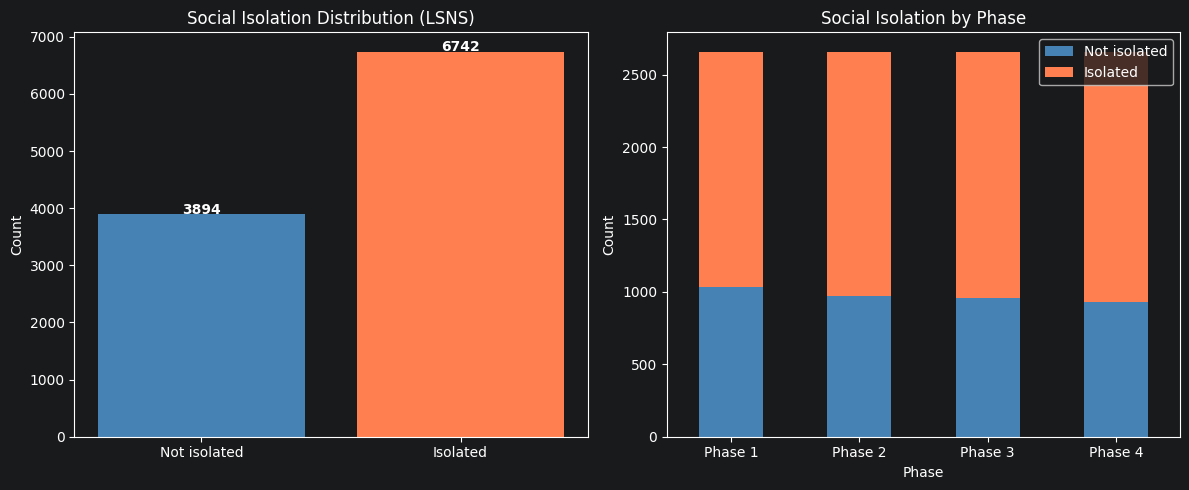

In [10]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_encoded[target_LSNS].value_counts().sort_index()   # -> index [0, 1]
axes[0].bar(class_names, counts.values, color=["steelblue", "coral"])
axes[0].set_title("Social Isolation Distribution (LSNS)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

phase_target = (df_encoded.groupby("Phase")[target_LSNS]
                .value_counts().unstack(fill_value=0)
                .reindex(columns=[0, 1], fill_value=0))
phase_target.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Social Isolation by Phase")
axes[1].set_ylabel("Count")
axes[1].legend(class_names)
axes[1].set_xticklabels([f"Phase {i}" for i in phase_target.index], rotation=0)

plt.tight_layout()
plt.show()

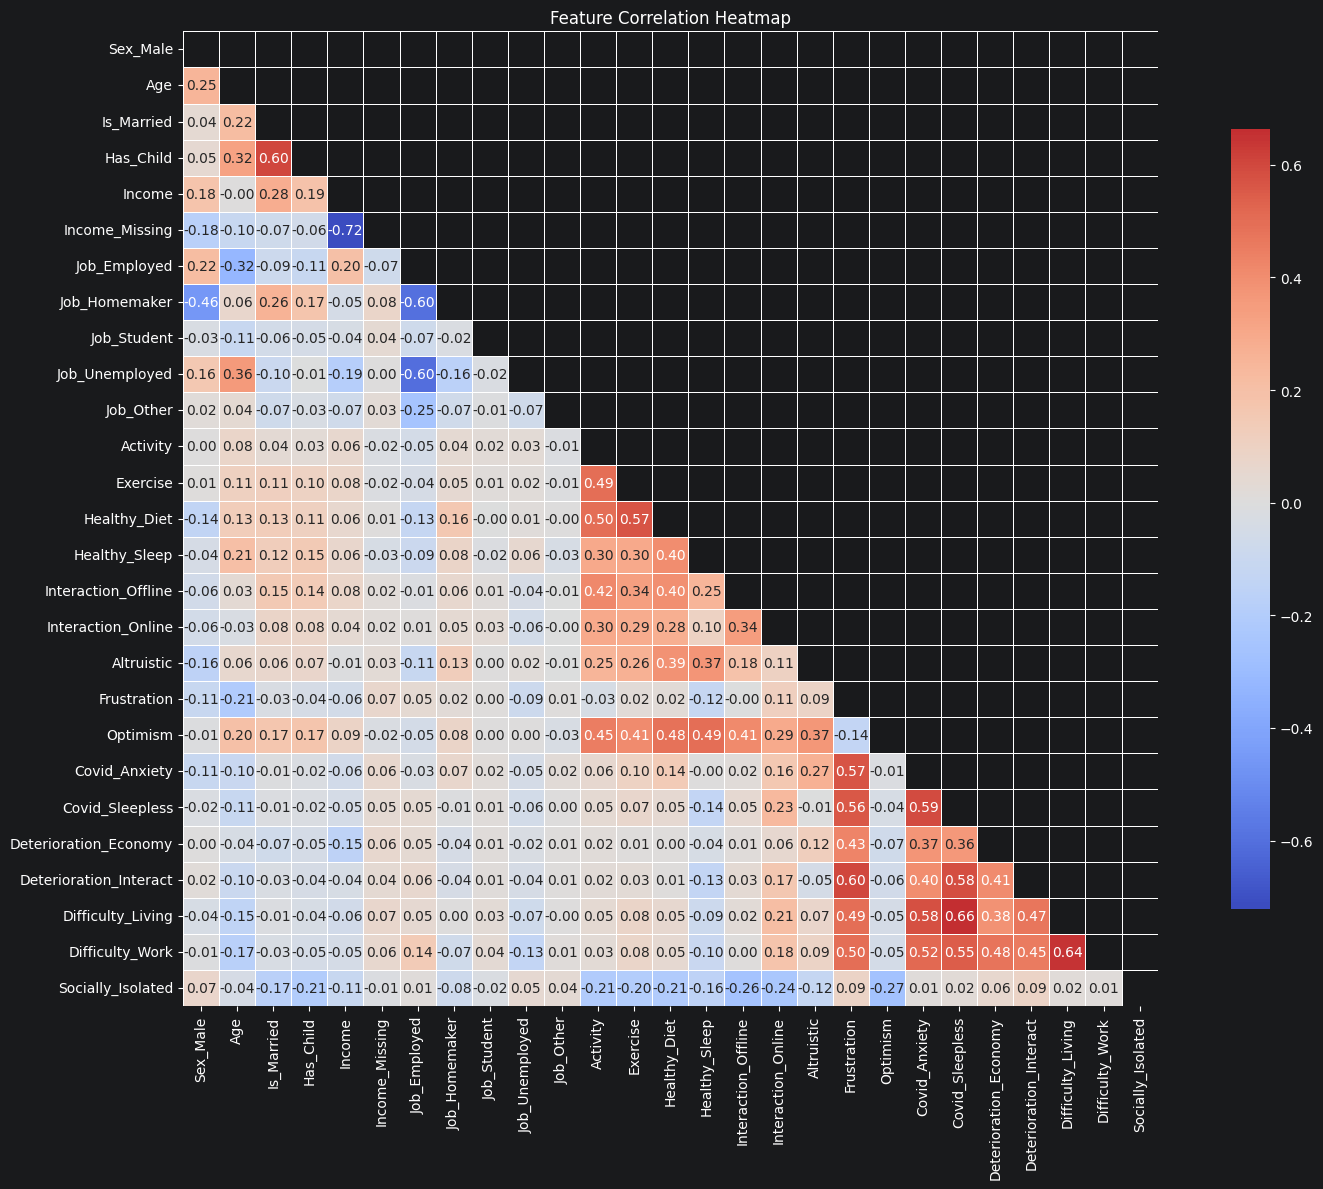

In [11]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df_encoded[features_LSNS + [target_LSNS]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

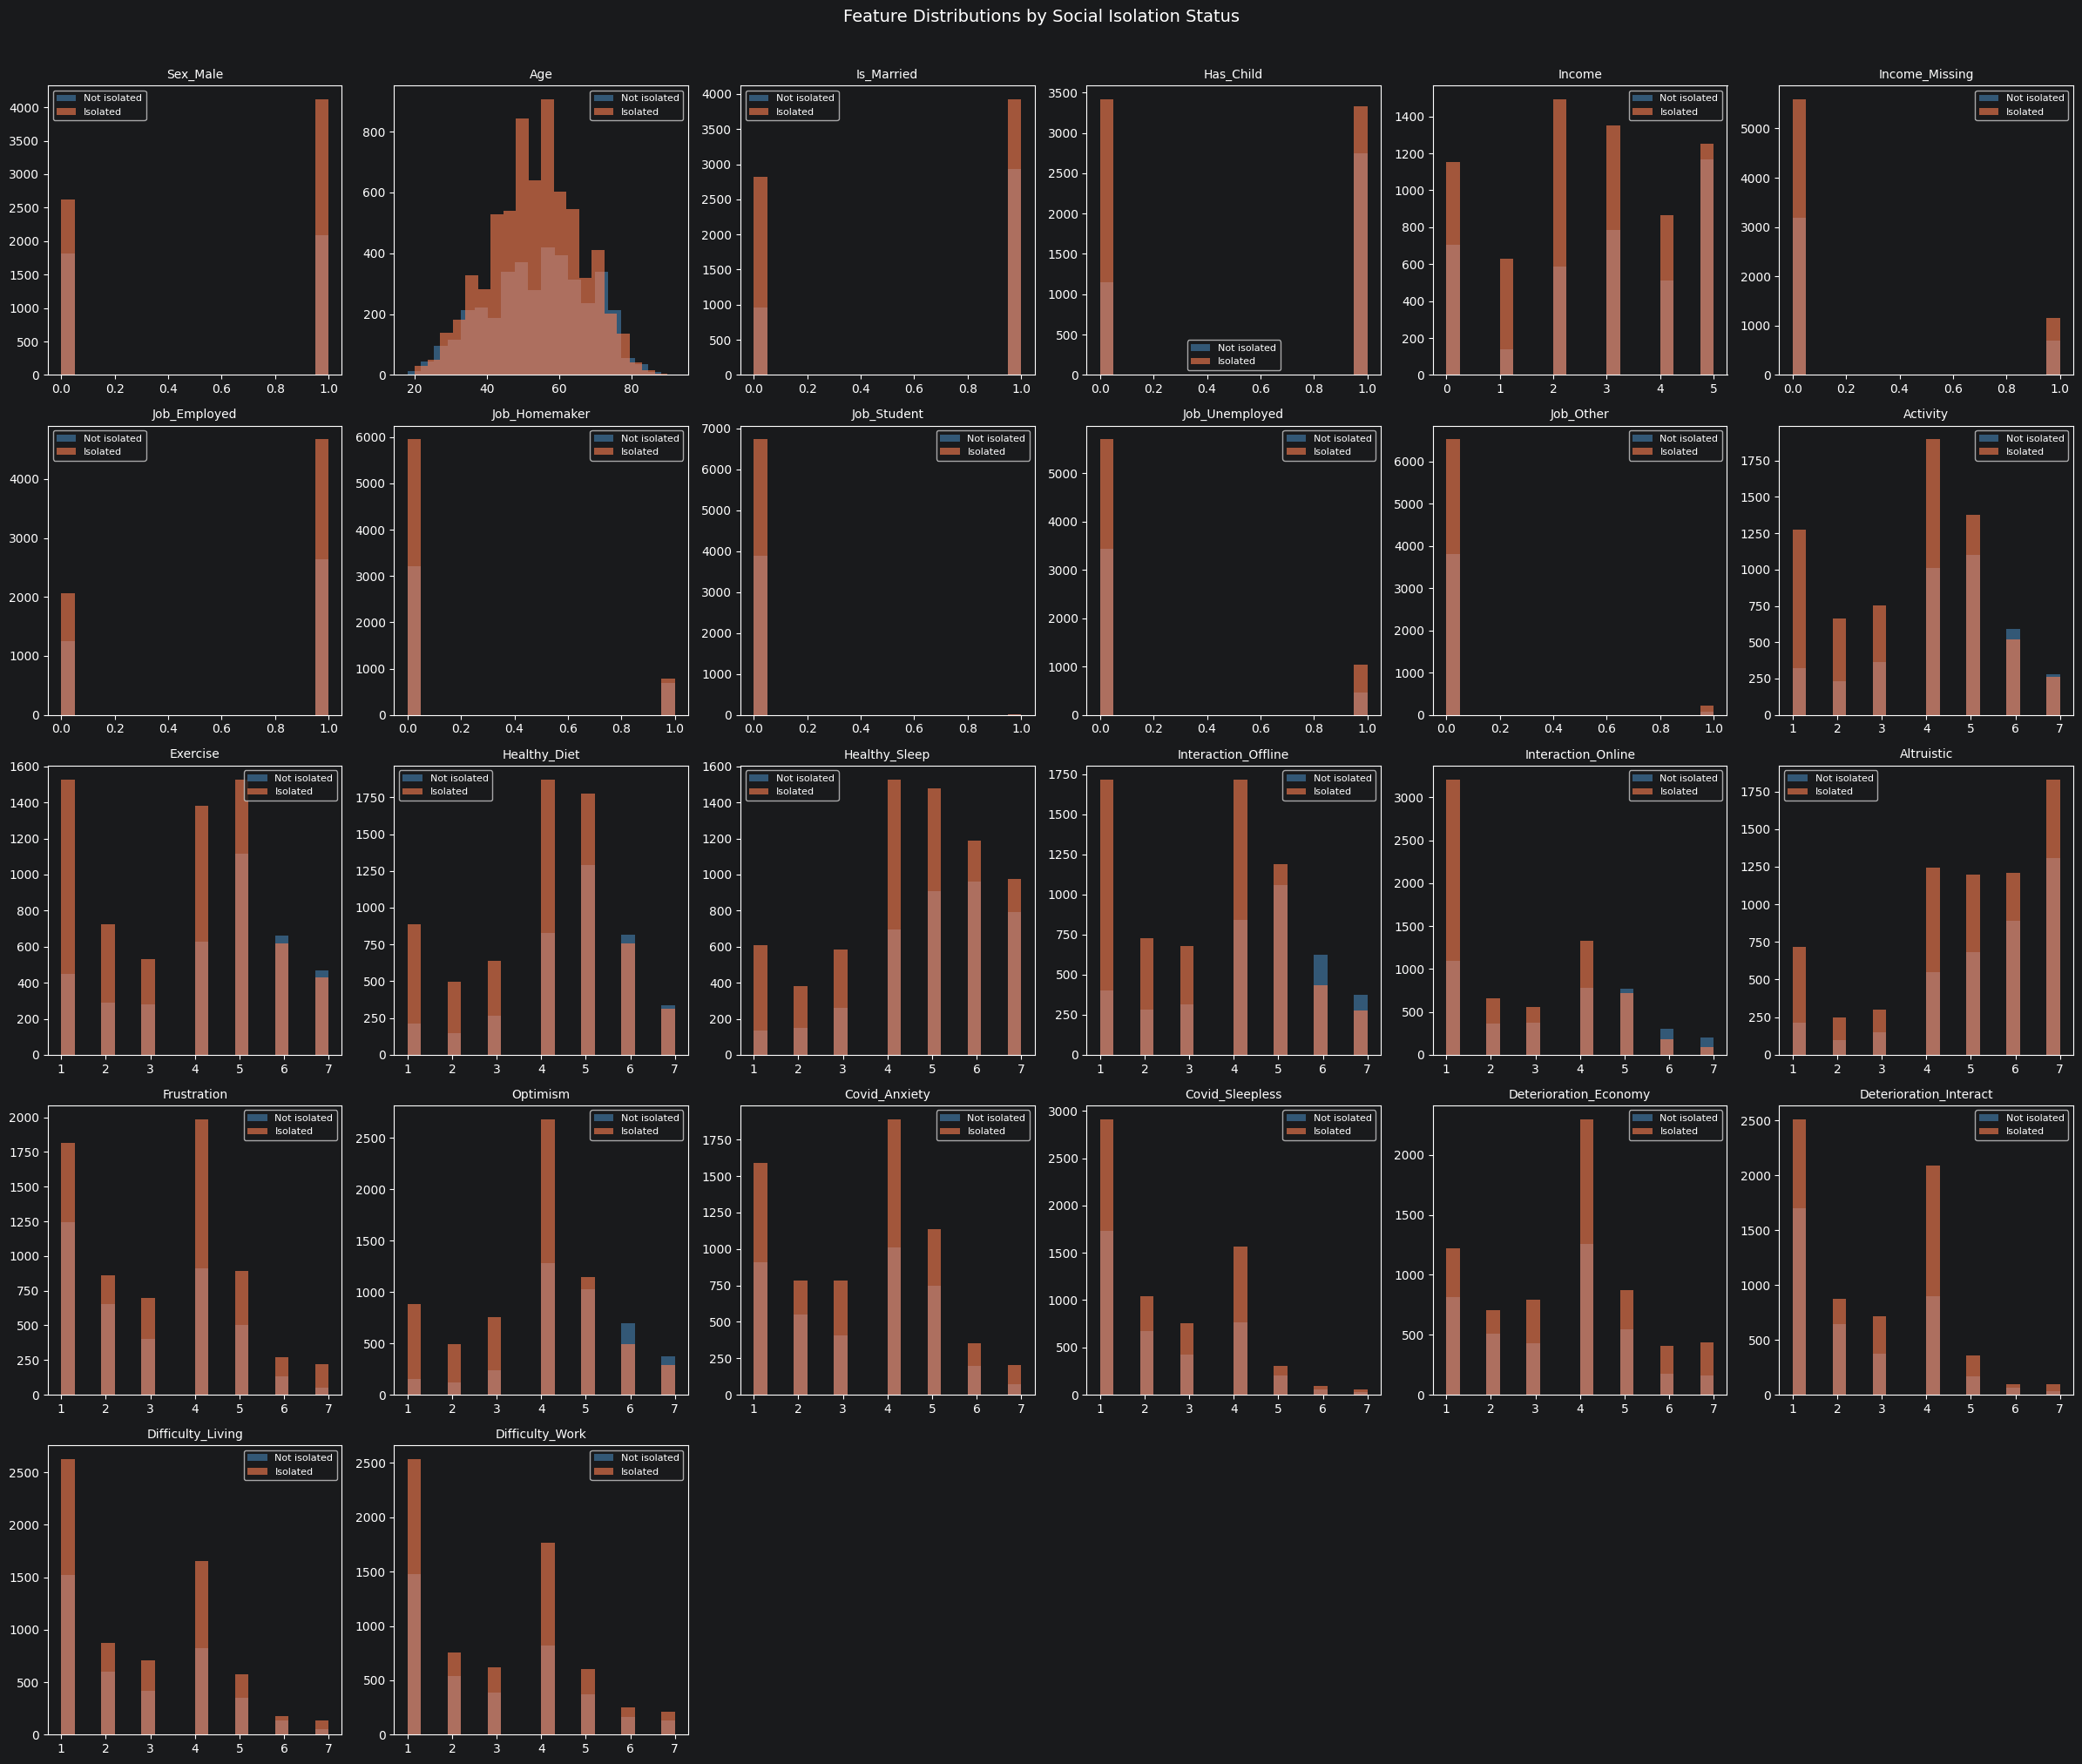

In [12]:
# Feature distributions by target class
fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for i, feat in enumerate(features_LSNS):
    if i < len(axes):
        for label, color in zip([0, 1], ["steelblue", "coral"]):
            subset = df_encoded[df_encoded[target_LSNS] == label][feat]
            axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                        label=class_names[label])
        axes[i].set_title(feat, fontsize=10)
        axes[i].legend(fontsize=8)

for j in range(len(features_LSNS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Social Isolation Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4. Train-Test Split

In [13]:
df_ml = df_encoded.copy()
df_train = df_ml[df_ml["Phase"].isin([1, 2, 3])].copy()
df_test = df_ml[df_ml["Phase"] == 4].copy()

ignore_feats = vars_LSNS
X_train = df_train.drop(columns=[target_LSNS] + ignore_feats, errors="ignore")
y_train = df_train[target_LSNS]
X_test = df_test.drop(columns=[target_LSNS] + ignore_feats, errors="ignore")
y_test = df_test[target_LSNS]

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set: 7977 samples, 26 features
Testing set:  2659 samples, 26 features

Training target distribution:
Socially_Isolated
1    5016
0    2961
Name: count, dtype: int64

Test target distribution:
Socially_Isolated
1    1726
0     933
Name: count, dtype: int64


# 5. PCA for Feature Engineering

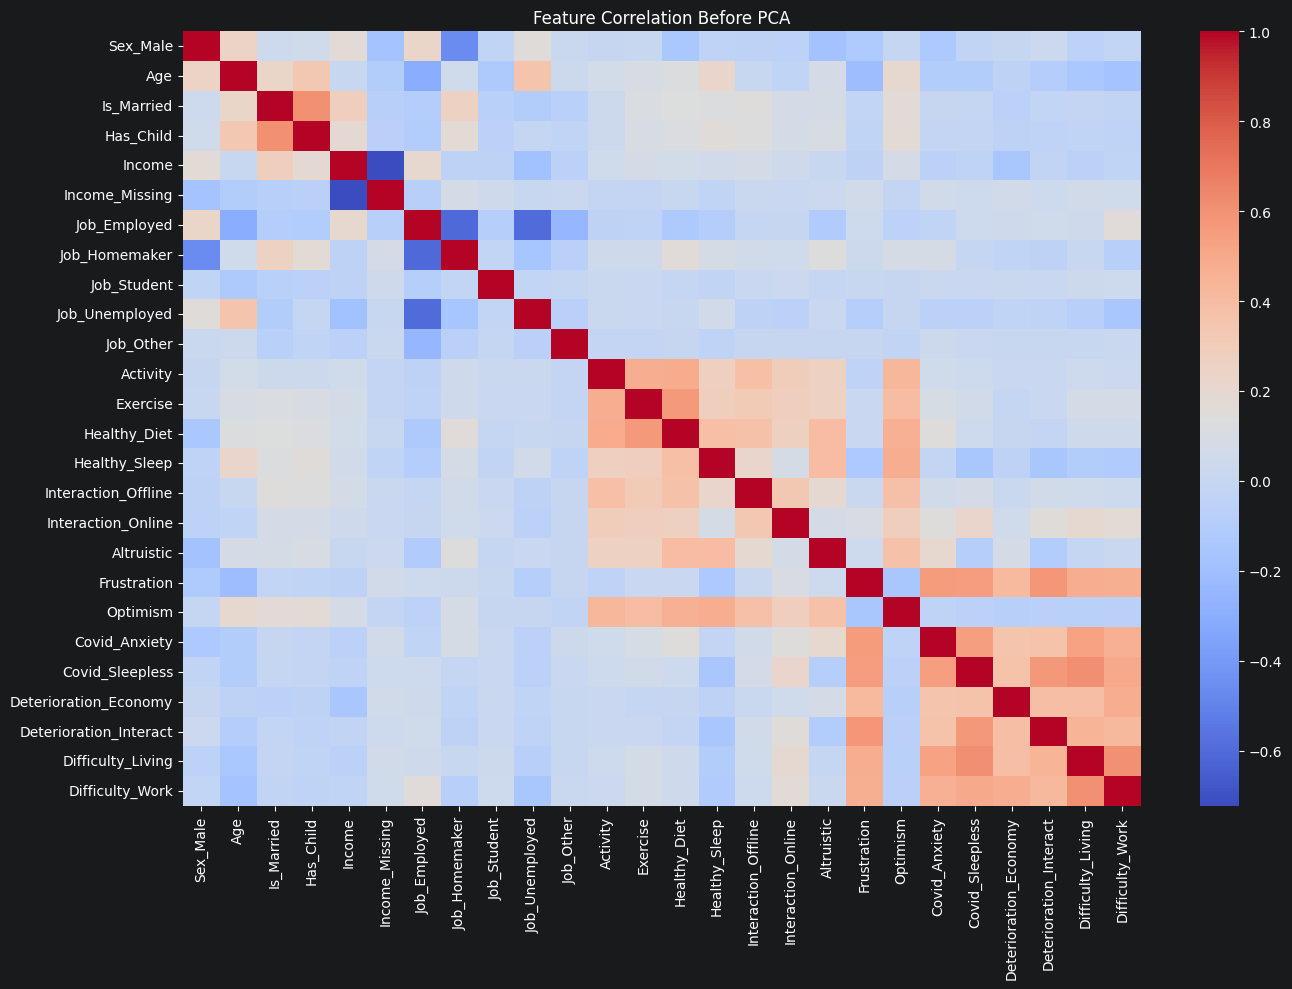

In [14]:
# Standardize features before PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Correlation heatmap before PCA
plt.figure(figsize=(14, 10))
sns.heatmap(X_train_scaled_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Before PCA")
plt.tight_layout()
plt.show()

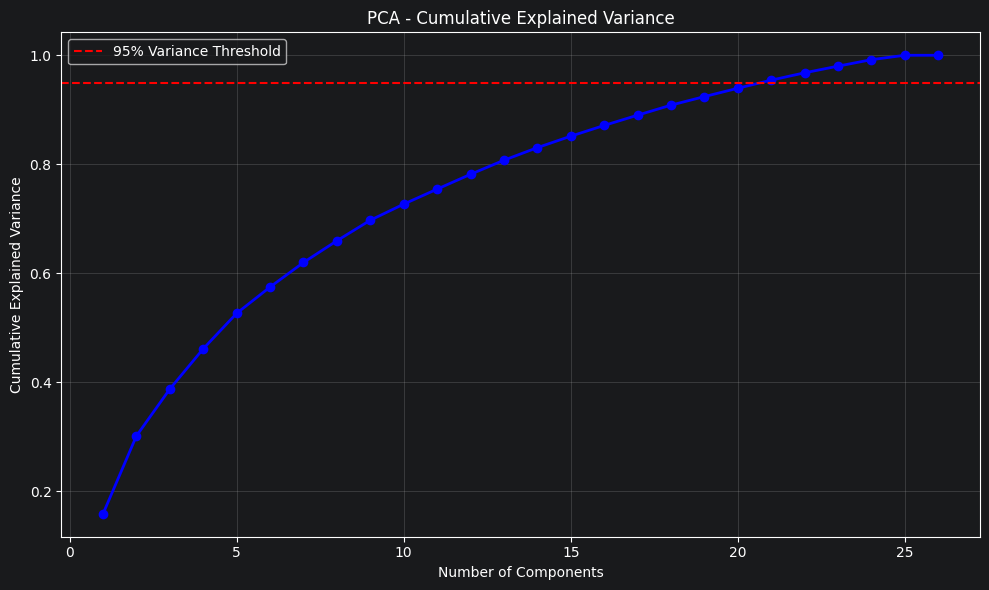

Optimal number of components (95% variance): 21
Original number of features: 26
Dimensionality reduction: 26 -> 21 (19.2% reduction)


In [15]:
# Fit PCA to determine optimal components
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, "bo-", linewidth=2)
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance Threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optimal number of components
optimal_n = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of components (95% variance): {optimal_n}")
print(f"Original number of features: {X_train.shape[1]}")
print(f"Dimensionality reduction: {X_train.shape[1]} -> {optimal_n} ({(1 - optimal_n/X_train.shape[1])*100:.1f}% reduction)")

In [16]:
# Apply PCA with optimal components
pca_optimal = PCA(n_components=optimal_n)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

# Create DataFrames with PCA feature names
pca_feature_names = [f"PC{i+1}" for i in range(optimal_n)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_feature_names)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_feature_names)

print(f"PCA Training set: {X_train_pca_df.shape}")
print(f"PCA Testing set:  {X_test_pca_df.shape}")

PCA Training set: (7977, 21)
PCA Testing set:  (2659, 21)


In [17]:
# Top contributing features per principal component
loadings = pd.DataFrame(pca_optimal.components_.T,
                        columns=pca_feature_names,
                        index=X_train.columns)

print("Top contributing features per PC:")
for pc in pca_feature_names[:min(5, len(pca_feature_names))]:
    top_feats = loadings[pc].abs().nlargest(5)
    print(f"{pc} ({pca_optimal.explained_variance_ratio_[int(pc[2:])-1]*100:.1f}% variance):")
    for feat, val in top_feats.items():
        print(f"  {feat}: {val:.4f}")

Top contributing features per PC:
PC1 (15.9% variance):
  Covid_Sleepless: 0.3882
  Difficulty_Living: 0.3811
  Frustration: 0.3798
  Difficulty_Work: 0.3712
  Covid_Anxiety: 0.3498
PC2 (14.3% variance):
  Healthy_Diet: 0.3969
  Optimism: 0.3728
  Exercise: 0.3461
  Activity: 0.3337
  Healthy_Sleep: 0.3069
PC3 (8.6% variance):
  Job_Employed: 0.4930
  Income: 0.4802
  Income_Missing: 0.3943
  Job_Homemaker: 0.3354
  Sex_Male: 0.3206
PC4 (7.4% variance):
  Has_Child: 0.4446
  Is_Married: 0.4413
  Age: 0.3490
  Job_Employed: 0.2960
  Job_Homemaker: 0.2401
PC5 (6.5% variance):
  Job_Unemployed: 0.5335
  Sex_Male: 0.4771
  Job_Homemaker: 0.4349
  Age: 0.3630
  Is_Married: 0.2123


In [18]:
# Save PCA artifacts
joblib.dump(scaler, "models/pca_scaler.joblib")
joblib.dump(pca_optimal, "models/pca_transformer.joblib")
print("PCA scaler and transformer saved.")

PCA scaler and transformer saved.


In [19]:
# Use PCA dataframes for training
X_train = X_train_pca_df
X_test = X_test_pca_df

# 5. Baseline Model Training

In [20]:
# Define all models with default hyperparameters
models = [
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Support Vector Machine", SVC(random_state=random_state, probability=True)),
    ("MLP Classifier", MLPClassifier(random_state=random_state, max_iter=500)),
    ("TabPFN", TabPFNClassifier(device=device, random_state=random_state))
]

In [21]:
# Train and evaluate all baseline models
results = []
trained_models = {}
cm_data = {}

for name, model in models:
    print(f"\n{'='*60}")
    print(f"  {name} (baseline)")
    print(f"{'='*60}")

    # Train
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    # Predict
    start_test = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_test

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)   # 1 = isolated
    auc = roc_auc_score(y_test, y_prob)

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC:  {auc:.4f}")
    print(f"  Train:    {format_time(train_time)}")
    print(f"  Predict:  {format_time(test_time)}")
    print(f"\n{classification_report(y_test, y_pred, target_names=class_names)}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC AUC": auc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })

    trained_models[name] = model
    cm_data[name] = confusion_matrix(y_test, y_pred)

df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("  All baseline models trained.")
print("="*60)


  Random Forest (baseline)
  Accuracy: 0.7108
  F1-Score: 0.7856
  ROC AUC:  0.7517
  Train:    2.68s
  Predict:  0.03s

              precision    recall  f1-score   support

Not isolated       0.60      0.52      0.56       933
    Isolated       0.76      0.82      0.79      1726

    accuracy                           0.71      2659
   macro avg       0.68      0.67      0.67      2659
weighted avg       0.70      0.71      0.70      2659


  K-Nearest Neighbors (baseline)
  Accuracy: 0.6736
  F1-Score: 0.7521
  ROC AUC:  0.6999
  Train:    0.00s
  Predict:  0.07s

              precision    recall  f1-score   support

Not isolated       0.54      0.51      0.52       933
    Isolated       0.74      0.76      0.75      1726

    accuracy                           0.67      2659
   macro avg       0.64      0.64      0.64      2659
weighted avg       0.67      0.67      0.67      2659


  Decision Tree (baseline)
  Accuracy: 0.6164
  F1-Score: 0.6973
  ROC AUC:  0.5899
  Train:   

# 6. Results & Comparison

In [22]:
# Results table
display(df_results.sort_values("F1-Score", ascending=False))

,Model,Accuracy,F1-Score,ROC AUC,Train Time (s),Test Time (s)
4,Support Vector Machine,0.717187,0.795541,0.748586,8.615879,0.493917
6,TabPFN,0.722828,0.795107,0.764428,0.806193,8.305052
0,Random Forest,0.710794,0.785615,0.751669,2.681980,0.025136
3,Gaussian Naive Bayes,0.694246,0.777808,0.721188,0.002038,0.000954
5,MLP Classifier,0.689733,0.760383,0.718155,5.866041,0.004132
1,K-Nearest Neighbors,0.673561,0.752142,0.699913,0.001515,0.073929
2,Decision Tree,0.616397,0.697329,0.589912,0.214348,0.001055


In [23]:
# Confusion matrices
for name in cm_data:
    cm = cm_data[name]
    fig_cm = ff.create_annotated_heatmap(
        z=cm.tolist(),
        x=["Predicted Not isolated", "Predicted Isolated"],
        y=["Actual Not isolated", "Actual Isolated"],
        annotation_text=[[str(y) for y in x] for x in cm.tolist()],
        colorscale="Viridis"
    )
    fig_cm.update_layout(title_text=f"Confusion Matrix (Baseline): {name}",
                         yaxis=dict(autorange="reversed"), height=350)
    fig_cm.show()

# 7. Save Models & Results

In [24]:
# Save all baseline models
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    save_path = f"models/baseline_pca_{safe_name}.joblib"
    joblib.dump(model, save_path)
    print(f"Saved: {save_path}")

# Save results
df_results.to_csv("models/baseline_pca_comparison_results.csv", index=False)
print("\nBaseline comparison results saved to models/baseline_comparison_results.csv")

# Save training data
X_train.to_csv("artifacts/X_train.csv", index=False)
X_test.to_csv("artifacts/X_test.csv", index=False)
y_train.to_csv("artifacts/y_train.csv", index=False)
y_test.to_csv("artifacts/y_test.csv", index=False)
print("Training/test data saved.")

Saved: models/baseline_pca_random_forest.joblib
Saved: models/baseline_pca_k_nearest_neighbors.joblib
Saved: models/baseline_pca_decision_tree.joblib
Saved: models/baseline_pca_gaussian_naive_bayes.joblib
Saved: models/baseline_pca_support_vector_machine.joblib
Saved: models/baseline_pca_mlp_classifier.joblib
Saved: models/baseline_pca_tabpfn.joblib

Baseline comparison results saved to models/baseline_comparison_results.csv
Training/test data saved.
